In [6]:
from pathlib import Path

from config import PLOTS_DIR
from core.sharpe_avar_sensitivity import (
    run_analysis, 
    AVarSensitivityFramework, StandardConstraints
)

In [7]:
def _example_garch() -> AVarSensitivityFramework:
    def avar(sr, alpha=0.08, beta=0.87, skew=0.0, exc_kurt=0.0, **kw):
        t1 = skew * (1 - beta) / (1 - alpha - beta)
        t2 = ((exc_kurt + 2) * (1 - beta) ** 2 * (1 + alpha + beta)
              / ((1 - alpha - beta) * (1 - 2 * alpha * beta - beta ** 2)))
        return 1 - sr * t1 + sr ** 2 / 4 * t2

    constraints = [
        StandardConstraints.garch_stationarity(),
        StandardConstraints.garch_fourth_moment(kurt="exc_kurt"),
        StandardConstraints.kurtosis_lower_bound("exc_kurt"),
        StandardConstraints.positive("sr"),
        #StandardConstraints.positive("omega"),
    ]
    return AVarSensitivityFramework(avar, constraints=constraints, name="GARCH11")

def _example_ar1_garch11_symm():
    def avar(sr, rho=0.2, alpha=0.08, beta=0.87, exc_kurt=0.0, **kw):
        k_r = exc_kurt + 3
        phi2 = rho ** 2
        den_com = 1 - 2 * alpha * beta - beta ** 2
        K = (1 + phi2) * k_r - 5 * phi2 - 1
        num_A = 1 - alpha * beta - beta ** 2
        factor_A = 1 - phi2 * (alpha + beta)
        A = 6 * phi2 * alpha * (num_A / den_com) * (1 / factor_A)
        params_ratio = ((1 - beta) ** 2 * (1 + alpha + beta)) / ((1 - alpha - beta) * den_com)
        S_vv = (1 / (1 - phi2)) * (4 * phi2 + (K / (1 + A)) * ((2 / 3) * A + params_ratio))
        return (1 + rho) / (1 - rho) + 0.25 * sr ** 2 * S_vv

    # Don't pass parameters — let the sniffer demonstrate auto-introspection.
    constraints = [
        StandardConstraints.garch_stationarity(),
        StandardConstraints.garch_fourth_moment(kurt="exc_kurt"),
        StandardConstraints.ar_stationarity("rho"),
        StandardConstraints.kurtosis_lower_bound("exc_kurt"),
        StandardConstraints.positive("sr"),
        #StandardConstraints.positive("omega"),
    ]
    return AVarSensitivityFramework(avar, constraints=constraints, name="AR1-GARCH11-symm")


Model: AR1-GARCH11-symm
Parameters: ['sr', 'rho', 'alpha', 'beta', 'exc_kurt']
Base point: {'sr': 0.5, 'rho': 0.2, 'alpha': 0.08, 'beta': 0.87, 'exc_kurt': 0.0}
Base AVar: 2.2805
Constraints:
  - alpha + beta < 1
  - kappa_z * alpha^2 + 2*alpha*beta + beta^2 < 1
  - |rho| < 1
  - exc_kurt > -2
  - sr > 0

1. OAT SWEEPS (feasible only; omega skipped; alpha+beta added)
  sr            n= 100   AVar in [1.500, 13.988]
  rho           n= 200   AVar in [0.905, 20.335]
  alpha         n=  47   AVar in [1.636, 7.878]
  beta          n= 186   AVar in [1.656, 9.944]
  exc_kurt      n= 132   AVar in [2.280, 7.772]

2. MONTE CARLO (n=4000, feasible only)
  drew 4000 feasible samples

  AVar quantiles:
0.05     0.716
0.25     2.859
0.50     6.899
0.75    15.759
0.95    43.487
0.99    88.267

  Spearman rank corr(AVar, param):
sr          0.7533
exc_kurt    0.3317
rho         0.2285
beta        0.0954
alpha      -0.0304


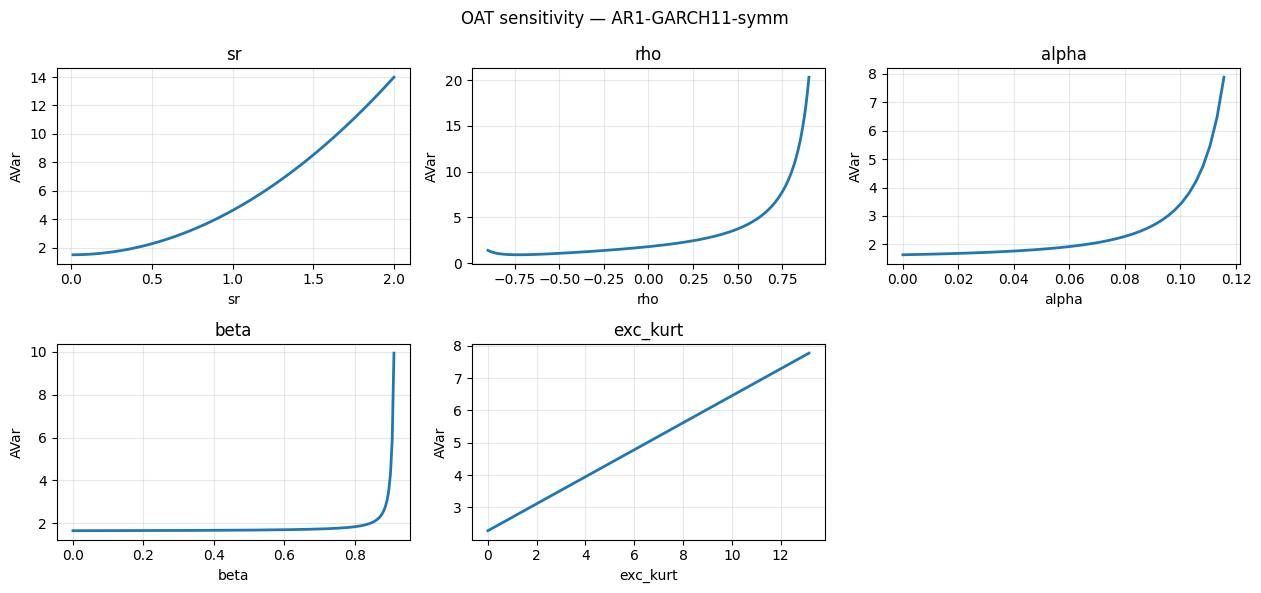

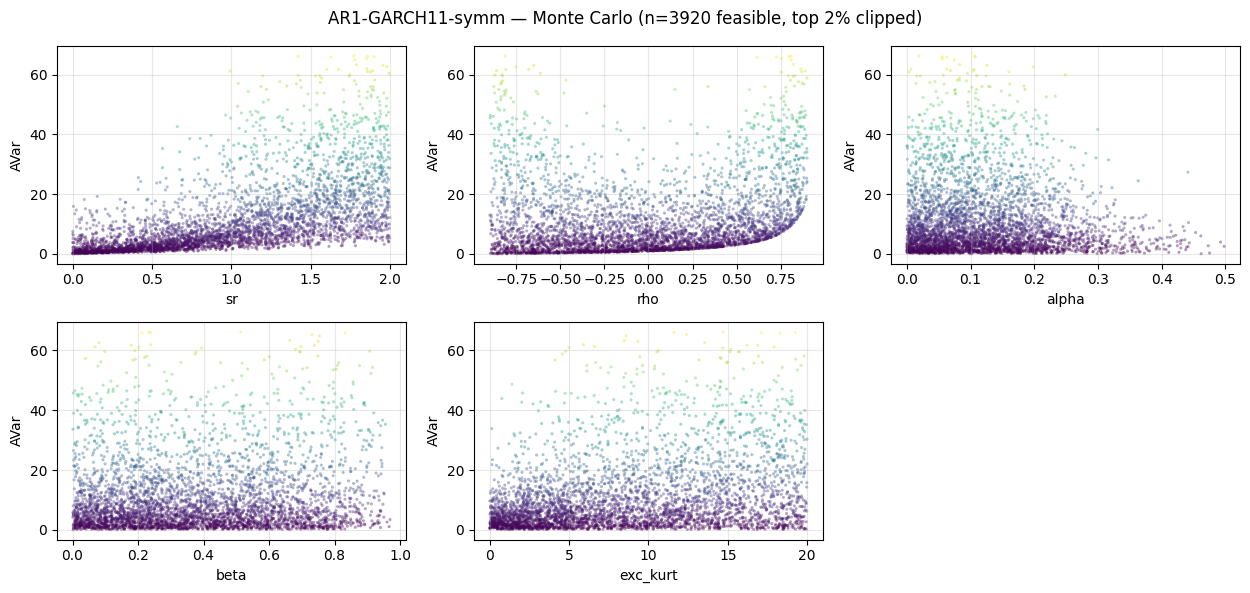

In [8]:
run_analysis(_example_ar1_garch11_symm(), PLOTS_DIR / "ar1_garch11_symm")

Model: GARCH11
Parameters: ['sr', 'alpha', 'beta', 'skew', 'exc_kurt']
Base point: {'sr': 0.5, 'alpha': 0.08, 'beta': 0.87, 'skew': 0.0, 'exc_kurt': 0.0}
Base AVar: 1.7929
Constraints:
  - alpha + beta < 1
  - kappa_z * alpha^2 + 2*alpha*beta + beta^2 < 1
  - exc_kurt > -2
  - sr > 0

1. OAT SWEEPS (feasible only; omega skipped; alpha+beta added)
  sr            n= 100   AVar in [1.000, 13.687]
  alpha         n=  47   AVar in [1.125, 7.985]
  beta          n= 186   AVar in [1.147, 10.103]
  skew          n= 200   AVar in [-2.107, 5.693]
  exc_kurt      n= 132   AVar in [1.793, 7.013]

2. MONTE CARLO (n=4000, feasible only)
  drew 4000 feasible samples

  AVar quantiles:
0.05     0.385
0.25     1.341
0.50     3.896
0.75     9.786
0.95    21.966
0.99    33.960

  Spearman rank corr(AVar, param):
sr          0.7461
skew       -0.4269
exc_kurt    0.3448
beta        0.0924
alpha      -0.0138


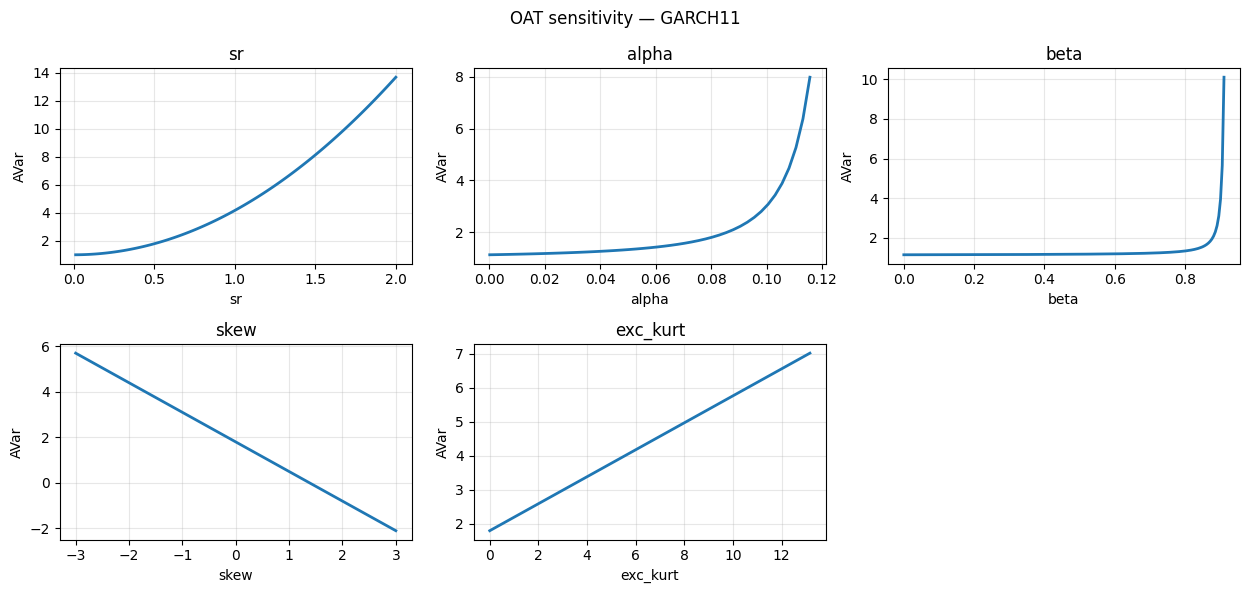

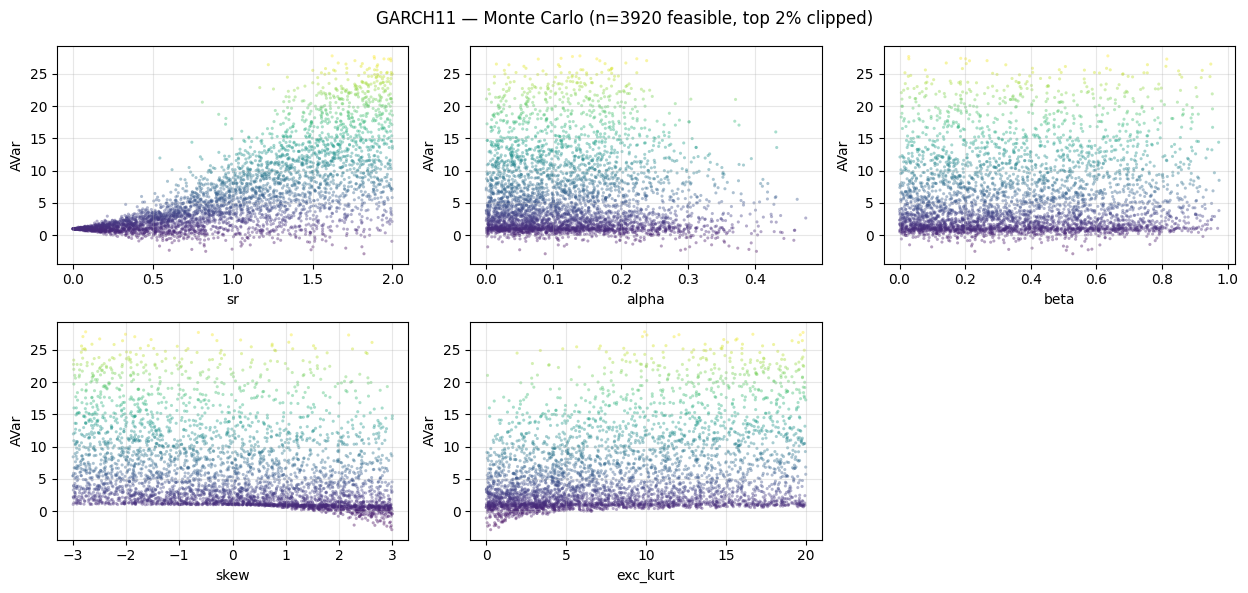

In [10]:
run_analysis(_example_garch(), PLOTS_DIR / "garch11")